# Seasonal Agriculture Performance Analysis
### Major Project — VOIS AICTE Batch 2026-2027

This notebook investigates how agricultural performance (yield, cost, revenue, profit, resource efficiency) varies across the three Indian cropping seasons — **Kharif, Rabi, and Zaid** — and whether those seasonal patterns hold consistently across states and crops.

**Structure:**
1. Setup & Data Loading
2. Data Cleaning & Feature Engineering
3. Outlier Analysis
4. Seasonal Summary Statistics
5. Statistical Hypothesis Testing (ANOVA + assumption checks + post-hoc)
6. Correlation Analysis (Pearson & Spearman)
7. State/Regional Analysis
8. Visualizations
9. Data-Driven Findings & Recommendations
10. Limitations


In [1]:
# ------------------------------------------------------------------------------
# SECTION 1: LIBRARY IMPORTS & ENVIRONMENT SETUP
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 14

print("Environment setup complete.")


Environment setup complete.


## Section 2: Data Loading & Initial Exploration

In [2]:
dataset_path = 'seasonal_agriculture_performance_dataset.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()


Dataset Shape: 4000 rows, 28 columns

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha       

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300


In [4]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000,3952.000,4000.000,4000.000,4000.000,4000.000,3960.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,3968.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,7.888,601.153,26.819,63.211,7.323,6.701,26.508,120.251,57.782,104.760,186.036,5.071,0.826,5.271,43.246,44714.166,526303.583,637860.048,111556.465,6045.570,5.385,46.366
std,4.224,288.925,3.818,11.961,1.121,0.641,6.712,31.216,17.015,27.743,60.261,1.979,0.102,13.361,126.881,30266.162,294419.141,636974.710,545081.891,5572.944,8.838,12.424
min,0.500,80.000,16.200,25.000,3.500,5.200,8.000,40.000,15.000,30.000,40.000,0.500,0.650,0.300,0.150,2594.000,26826.000,6107.000,-1019223.000,128.000,0.135,5.000
25%,4.260,370.200,23.900,54.775,6.600,6.260,21.700,98.500,46.200,86.200,143.975,3.690,0.740,1.050,5.020,21429.250,274577.500,207517.250,-148731.750,2268.750,1.661,37.300
50%,7.895,582.000,26.900,63.000,7.300,6.690,26.400,120.100,57.500,105.100,186.250,5.120,0.830,1.740,11.770,25913.000,519082.500,456830.500,3673.000,4435.000,2.938,46.400
75%,11.650,834.950,29.600,71.900,8.100,7.140,31.300,141.225,69.400,123.600,227.200,6.400,0.910,2.840,24.355,68279.000,761996.500,836874.750,216187.750,7829.750,5.150,54.900
max,15.000,1395.200,39.700,95.000,11.000,8.400,47.000,220.000,120.000,200.000,400.000,12.080,1.000,101.440,1424.400,131240.000,1349990.000,5080900.000,4345421.000,40902.000,79.800,88.900


## Section 3: Data Cleaning & Preprocessing

**Note on approach:** missing numeric values are imputed using the median within each `Crop`×`Season` group (falling back to the overall median if a group itself has no valid values), since agronomic values are expected to differ meaningfully by crop and season rather than being globally uniform.

In [5]:
# 3.1 Missing Value Audit
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
print("Missing values per feature:\n", missing_cols)


Missing values per feature:
 Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [6]:
# 3.2 Numerical imputation with group median (Crop x Season), fallback to overall median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df.groupby(['Crop', 'Season'])[col].transform(lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())

# Categorical imputation with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [7]:
# 3.3 Duplicate check
duplicate_count = df.duplicated().sum()
print(f"Duplicate records found: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)


Duplicate records found: 0


### 3.4 Derived Feature Engineering

Both derived ratios are guarded against division-by-zero, which the original version of this pipeline did not do (a farm with `Total_Cost_INR` or `Farm_Area_Hectares` of 0 would otherwise raise or silently produce `inf`).

In [8]:
df['Profit_Margin_pct'] = np.where(df['Revenue_INR'] > 0, (df['Profit_INR'] / df['Revenue_INR']) * 100, 0)

df['Yield_per_Cost'] = np.where(
    (df['Total_Cost_INR'] > 0) & (df['Farm_Area_Hectares'] > 0),
    df['Yield_Tonnes_Ha'] / (df['Total_Cost_INR'] / df['Farm_Area_Hectares']),
    np.nan
)

print("Feature engineering complete.")
df[['Profit_Margin_pct', 'Yield_per_Cost']].describe()


Feature engineering complete.


,Profit_Margin_pct,Yield_per_Cost
count,4000.000,4000.000
mean,-45.492,0.000
std,158.085,0.000
min,-1461.851,0.000
25%,-60.193,0.000
50%,1.146,0.000
75%,32.886,0.000
max,85.921,0.002


## Section 4: Outlier Analysis (Profit_INR)

Roughly half of all records show negative profit, so before trusting any group means it's worth checking how much of the spread is driven by extreme outliers rather than genuine seasonal effects. Outliers are flagged using the standard 1.5×IQR rule.

Profit outliers: 404 records (10.10% of data)
IQR bounds: [-696,111, 763,567]


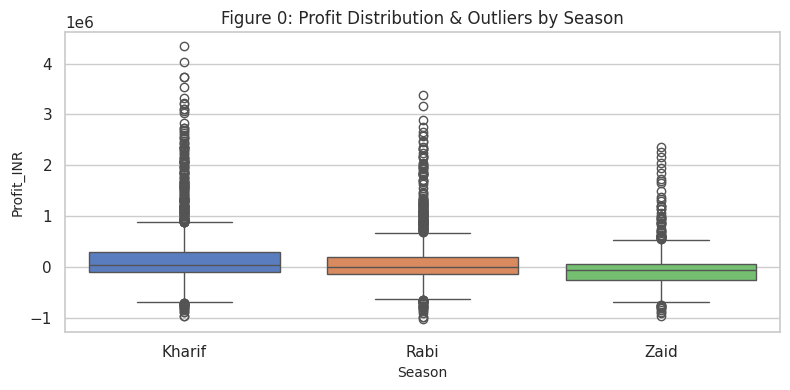

In [9]:
Q1, Q3 = df['Profit_INR'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df[(df['Profit_INR'] < lower_bound) | (df['Profit_INR'] > upper_bound)]
print(f"Profit outliers: {len(outliers)} records ({len(outliers)/len(df)*100:.2f}% of data)")
print(f"IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Season', y='Profit_INR', hue='Season', legend=False)
plt.title('Figure 0: Profit Distribution & Outliers by Season')
plt.tight_layout()
plt.show()


**Note:** these outliers are kept in the analysis (not dropped) since group means/medians and non-parametric tests below are robust enough to still be informative, and removing ~10% of the data without an agronomic justification would bias the sample. If your instructor expects outlier removal, do it here with `df = df[(df['Profit_INR'] >= lower_bound) & (df['Profit_INR'] <= upper_bound)]` and re-run subsequent cells.

## Section 5: Seasonal Summary Statistics

In [10]:
seasonal_summary = df.groupby('Season').agg(
    Mean_Rainfall=('Rainfall_mm', 'mean'),
    Mean_Temp=('Avg_Temperature_C', 'mean'),
    Mean_Yield=('Yield_Tonnes_Ha', 'mean'),
    Mean_Production=('Production_Tonnes', 'mean'),
    Mean_Cost=('Total_Cost_INR', 'mean'),
    Mean_Revenue=('Revenue_INR', 'mean'),
    Mean_Profit=('Profit_INR', 'mean'),
    Mean_Water_Eff=('Water_Efficiency_t_per_1000m3', 'mean'),
    Mean_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
).reset_index()

seasonal_summary


,Season,Mean_Rainfall,Mean_Temp,Mean_Yield,Mean_Production,Mean_Cost,Mean_Revenue,Mean_Profit,Mean_Water_Eff,Mean_Pest_Risk
0,Kharif,852.104,28.454,5.631,46.311,531804.408,710719.056,178914.648,5.892,54.468
1,Rabi,435.948,23.489,5.095,41.487,513836.578,601526.049,87689.470,5.186,40.482
2,Zaid,299.163,31.042,4.637,38.886,543976.729,519171.904,-24804.825,4.413,38.217


## Section 6: Statistical Hypothesis Testing

Before running ANOVA, its two core assumptions are checked directly instead of being assumed:
- **Normality** of Yield within each season (Shapiro-Wilk)
- **Homogeneity of variance** across seasons (Levene's test)

With n≈1,300+ per season, Shapiro-Wilk will almost always reject normality on real-world-shaped data (it's oversensitive at large sample sizes) — ANOVA is still reasonably robust to this given the sample size, but it's worth reporting rather than skipping.

In [11]:
# 6.1 Assumption checks
seasons = df['Season'].unique()

print("--- Shapiro-Wilk Normality Test (Yield, sampled n=500 per season) ---")
for s in seasons:
    sample = df[df['Season'] == s]['Yield_Tonnes_Ha']
    stat, p = shapiro(sample.sample(min(500, len(sample)), random_state=42))
    print(f"{s}: W={stat:.4f}, p={p:.4e}")

lev_stat, lev_p = levene(*[df[df['Season'] == s]['Yield_Tonnes_Ha'] for s in seasons])
print(f"\nLevene's Test (equal variances): stat={lev_stat:.4f}, p={lev_p:.4f}")
print("-> Variances can be treated as equal across seasons." if lev_p > 0.05 else "-> Variances differ significantly across seasons.")


--- Shapiro-Wilk Normality Test (Yield, sampled n=500 per season) ---
Kharif: W=0.3949, p=1.0788e-37
Rabi: W=0.4025, p=1.5939e-37
Zaid: W=0.3752, p=4.0010e-38

Levene's Test (equal variances): stat=0.7519, p=0.4715
-> Variances can be treated as equal across seasons.


In [12]:
# 6.2 One-Way ANOVA: Yield across Seasons
yield_by_season = [df[df['Season'] == s]['Yield_Tonnes_Ha'] for s in seasons]
f_yield, p_yield = f_oneway(*yield_by_season)
print(f"ANOVA (Yield ~ Season): F = {f_yield:.4f}, p = {p_yield:.4e}")
print("-> Statistically significant difference in Yield across seasons." if p_yield < 0.05
      else "-> No statistically significant difference in mean Yield across seasons.")


ANOVA (Yield ~ Season): F = 1.4579, p = 2.3285e-01
-> No statistically significant difference in mean Yield across seasons.


In [13]:
# 6.3 One-Way ANOVA: Profit across Seasons
profit_by_season = [df[df['Season'] == s]['Profit_INR'] for s in seasons]
f_profit, p_profit = f_oneway(*profit_by_season)
print(f"ANOVA (Profit ~ Season): F = {f_profit:.4f}, p = {p_profit:.4e}")
print("-> Statistically significant difference in Profit across seasons." if p_profit < 0.05
      else "-> No statistically significant difference in mean Profit across seasons.")


ANOVA (Profit ~ Season): F = 34.2918, p = 1.7124e-15
-> Statistically significant difference in Profit across seasons.


### 6.4 Post-hoc Tukey HSD

ANOVA only tells you *that* a difference exists somewhere; Tukey HSD tells you *which* season pairs actually differ. Run this for whichever of the two ANOVAs above came back significant (Profit, based on this dataset).

In [14]:
print("Tukey HSD — Profit by Season")
tukey_profit = pairwise_tukeyhsd(df['Profit_INR'], df['Season'])
print(tukey_profit)


Tukey HSD — Profit by Season


       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
Kharif   Rabi  -91225.1774   0.0 -134704.3086  -47746.0461   True
Kharif   Zaid -203719.4725   0.0 -263782.6023 -143656.3426   True
  Rabi   Zaid -112494.2951   0.0 -173255.6664  -51732.9238   True
-----------------------------------------------------------------


In [15]:
print("Tukey HSD — Yield by Season (for completeness, even if ANOVA was not significant)")
tukey_yield = pairwise_tukeyhsd(df['Yield_Tonnes_Ha'], df['Season'])
print(tukey_yield)


Tukey HSD — Yield by Season (for completeness, even if ANOVA was not significant)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Kharif   Rabi  -0.5357 0.4708 -1.6086 0.5372  False
Kharif   Zaid  -0.9933 0.2583 -2.4754 0.4889  False
  Rabi   Zaid  -0.4576 0.7543 -1.9569 1.0418  False
---------------------------------------------------


## Section 7: Correlation Analysis

Both Pearson (linear) and Spearman (monotonic/rank-based) correlations are reported — Spearman is more appropriate given the non-normal distributions confirmed above, and comparing the two also reveals if a relationship is non-linear.

In [16]:
corr_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Yield_Tonnes_Ha', 'Profit_INR']

pearson_corr = df[corr_vars].corr(method='pearson')
spearman_corr = df[corr_vars].corr(method='spearman')

print("Pearson Correlation:")
display(pearson_corr)


Pearson Correlation:


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.000,0.198,0.526,0.520,0.025,0.001,0.027,0.106
Avg_Temperature_C,0.198,1.000,0.138,0.083,0.016,0.007,0.009,0.009
Humidity_pct,0.526,0.138,1.000,0.451,0.025,-0.004,0.011,0.064
Soil_Moisture_pct,0.520,0.083,0.451,1.000,0.008,-0.023,0.010,0.092
Fertilizer_kg_ha,0.025,0.016,0.025,0.008,1.000,-0.001,-0.000,-0.074
Pesticide_Litre_ha,0.001,0.007,-0.004,-0.023,-0.001,1.000,-0.009,-0.026
Yield_Tonnes_Ha,0.027,0.009,0.011,0.010,-0.000,-0.009,1.000,0.489
Profit_INR,0.106,0.009,0.064,0.092,-0.074,-0.026,0.489,1.000


In [17]:
print("Spearman Correlation:")
display(spearman_corr)

# Identify the strongest relationship in the matrix (excluding the diagonal)
strongest_pair = pearson_corr.where(~np.eye(len(corr_vars), dtype=bool)).abs().stack().idxmax()
strongest_val = pearson_corr.loc[strongest_pair]
print(f"\nStrongest correlation in the matrix: {strongest_pair[0]} vs {strongest_pair[1]} (r = {strongest_val:.3f})")


Spearman Correlation:


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.000,0.220,0.546,0.538,0.025,0.006,0.131,0.143
Avg_Temperature_C,0.220,1.000,0.169,0.119,0.015,0.010,0.001,-0.005
Humidity_pct,0.546,0.169,1.000,0.466,0.028,-0.003,0.081,0.090
Soil_Moisture_pct,0.538,0.119,0.466,1.000,0.010,-0.018,0.098,0.112
Fertilizer_kg_ha,0.025,0.015,0.028,0.010,1.000,0.004,0.003,-0.102
Pesticide_Litre_ha,0.006,0.010,-0.003,-0.018,0.004,1.000,-0.001,-0.033
Yield_Tonnes_Ha,0.131,0.001,0.081,0.098,0.003,-0.001,1.000,0.489
Profit_INR,0.143,-0.005,0.090,0.112,-0.102,-0.033,0.489,1.000



Strongest correlation in the matrix: Rainfall_mm vs Humidity_pct (r = 0.526)


## Section 8: State-wise & Regional Analysis

The problem brief specifically asks whether seasonal patterns are *consistent across regions* — this needs `State` broken out, which a Season-only analysis cannot answer.

In [18]:
state_season_yield = df.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()
state_season_yield


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.682,3.468,4.442
Gujarat,6.338,5.666,4.075
Karnataka,6.458,4.781,6.623
Madhya Pradesh,5.990,3.762,5.462
Maharashtra,5.433,5.502,2.267
Punjab,4.101,8.609,5.910
Tamil Nadu,5.521,4.496,4.098
Telangana,5.553,4.799,4.242


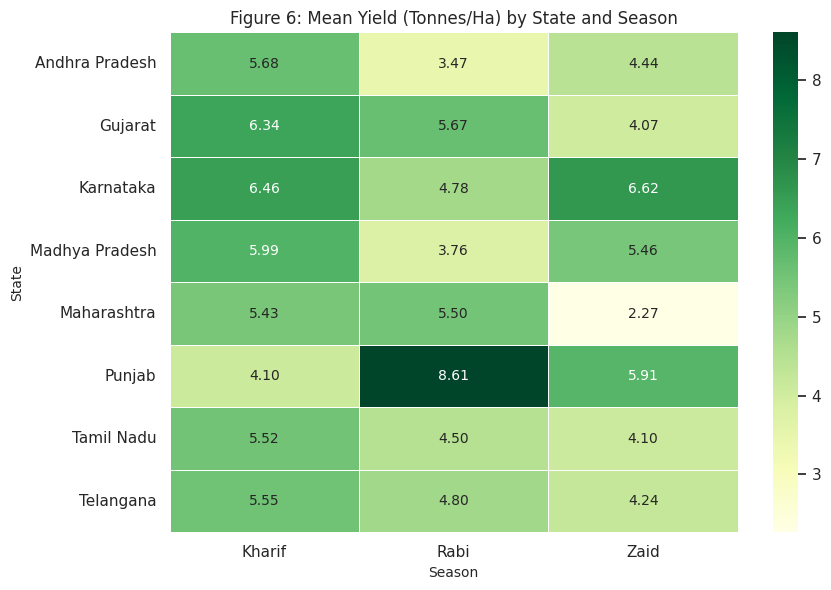

In [19]:
plt.figure(figsize=(9, 6))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Figure 6: Mean Yield (Tonnes/Ha) by State and Season')
plt.tight_layout()
plt.show()


In [20]:
# Coefficient of variation of each state's yield across seasons:
# high CV = that state's yield swings a lot between seasons; low CV = seasonally stable
state_cv = (state_season_yield.std(axis=1) / state_season_yield.mean(axis=1) * 100).sort_values(ascending=False)
print("Seasonal variability in Yield by State (Coefficient of Variation %):")
state_cv


Seasonal variability in Yield by State (Coefficient of Variation %):


State
Maharashtra      41.995
Punjab           36.558
Andhra Pradesh   24.492
Madhya Pradesh   22.955
Gujarat          21.691
Karnataka        17.119
Tamil Nadu       15.601
Telangana        13.518
dtype: float64

## Section 9: Visualization Pipeline

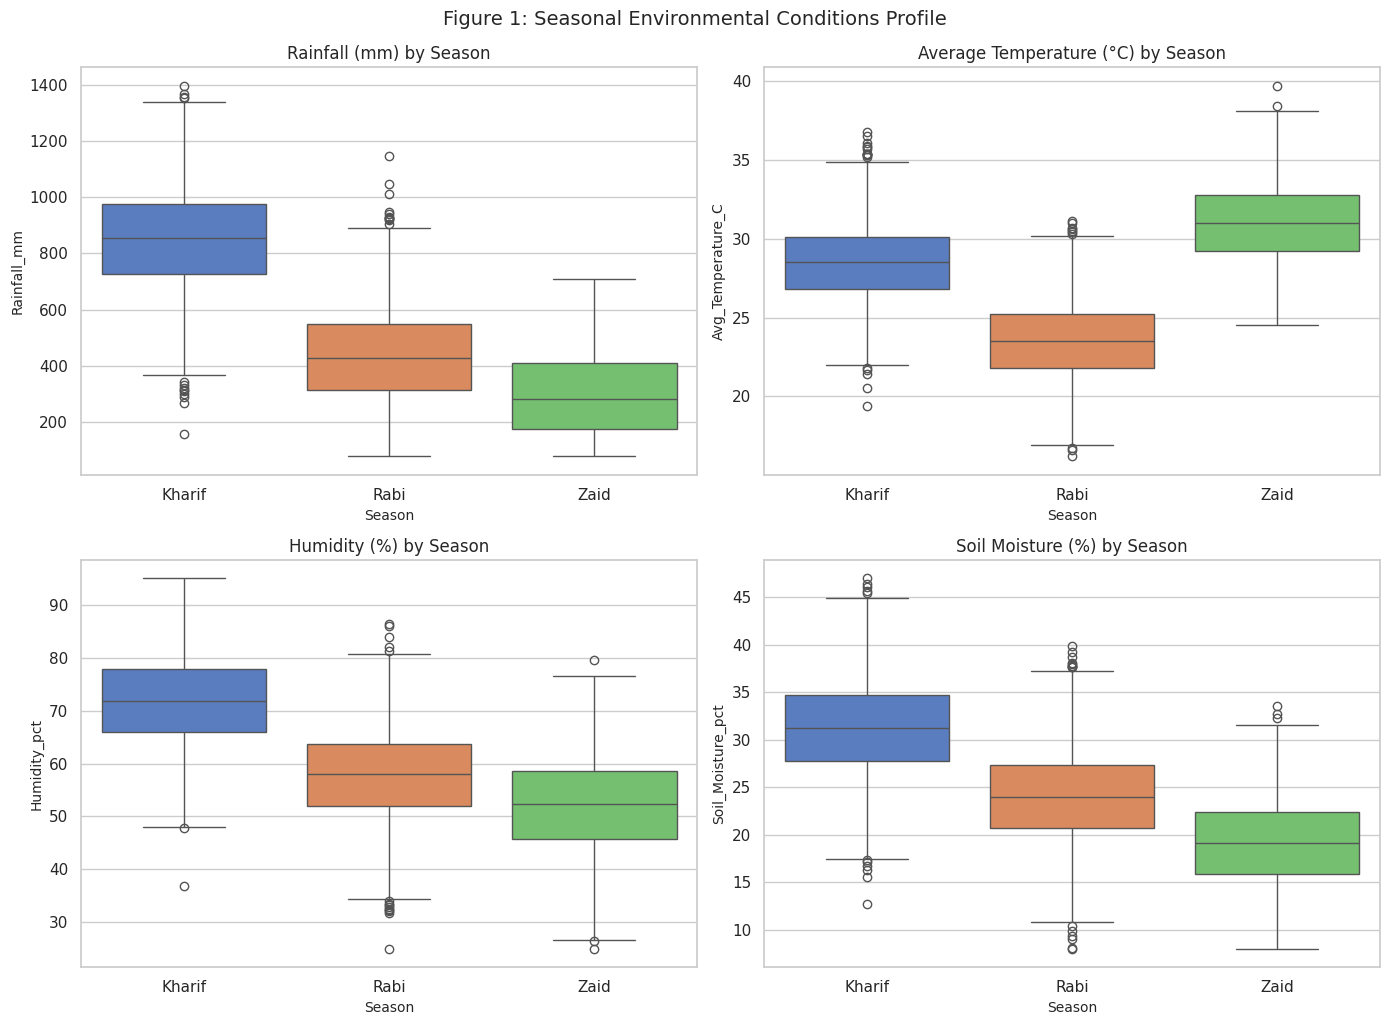

In [21]:
# Figure 1: Seasonal Distribution of Environmental Factors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df, x='Season', y='Rainfall_mm', hue='Season', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Rainfall (mm) by Season')

sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', hue='Season', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Average Temperature (°C) by Season')

sns.boxplot(data=df, x='Season', y='Humidity_pct', hue='Season', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Humidity (%) by Season')

sns.boxplot(data=df, x='Season', y='Soil_Moisture_pct', hue='Season', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Soil Moisture (%) by Season')

plt.tight_layout()
plt.suptitle('Figure 1: Seasonal Environmental Conditions Profile', y=1.02)
plt.show()


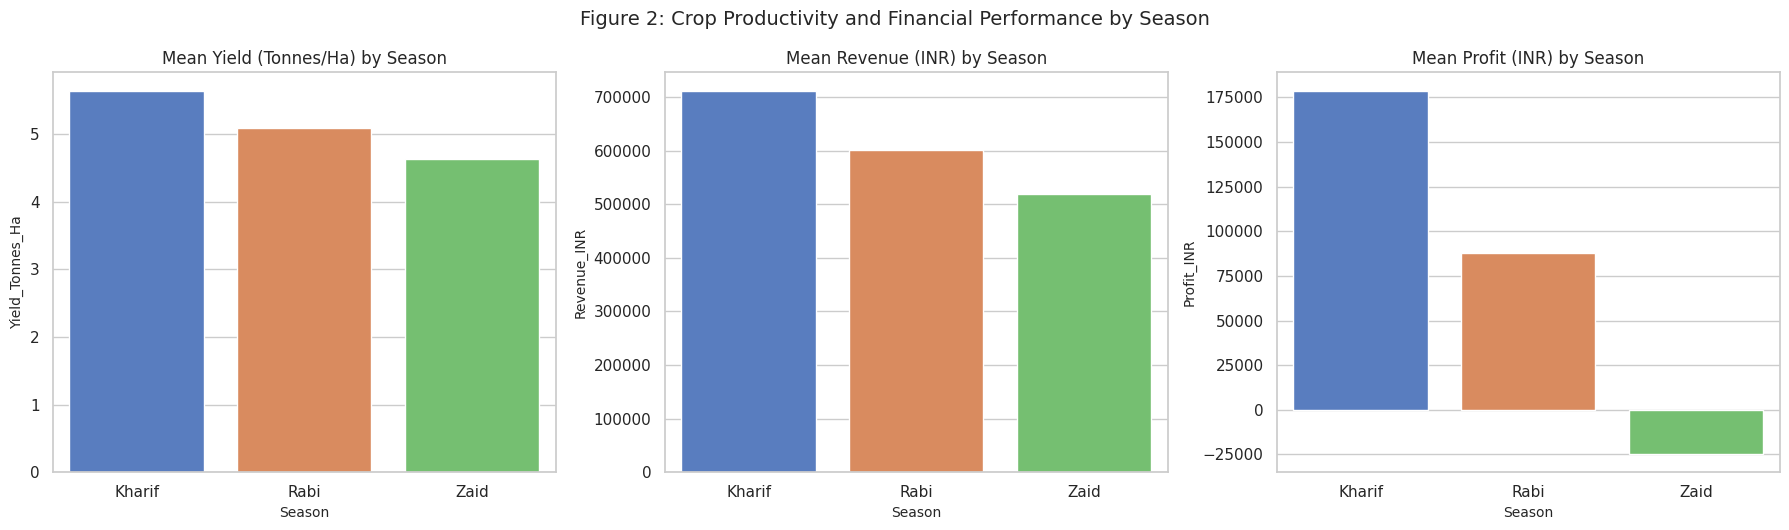

In [22]:
# Figure 2: Economic Outcomes & Yield Performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', legend=False, errorbar=None, ax=axes[0])
axes[0].set_title('Mean Yield (Tonnes/Ha) by Season')

sns.barplot(data=df, x='Season', y='Revenue_INR', hue='Season', legend=False, errorbar=None, ax=axes[1])
axes[1].set_title('Mean Revenue (INR) by Season')

sns.barplot(data=df, x='Season', y='Profit_INR', hue='Season', legend=False, errorbar=None, ax=axes[2])
axes[2].set_title('Mean Profit (INR) by Season')

plt.tight_layout()
plt.suptitle('Figure 2: Crop Productivity and Financial Performance by Season', y=1.05)
plt.show()


**Note:** `errorbar=None` replaces the deprecated `ci=None` argument — recent seaborn versions (0.13+) will raise a warning or error on `ci`.

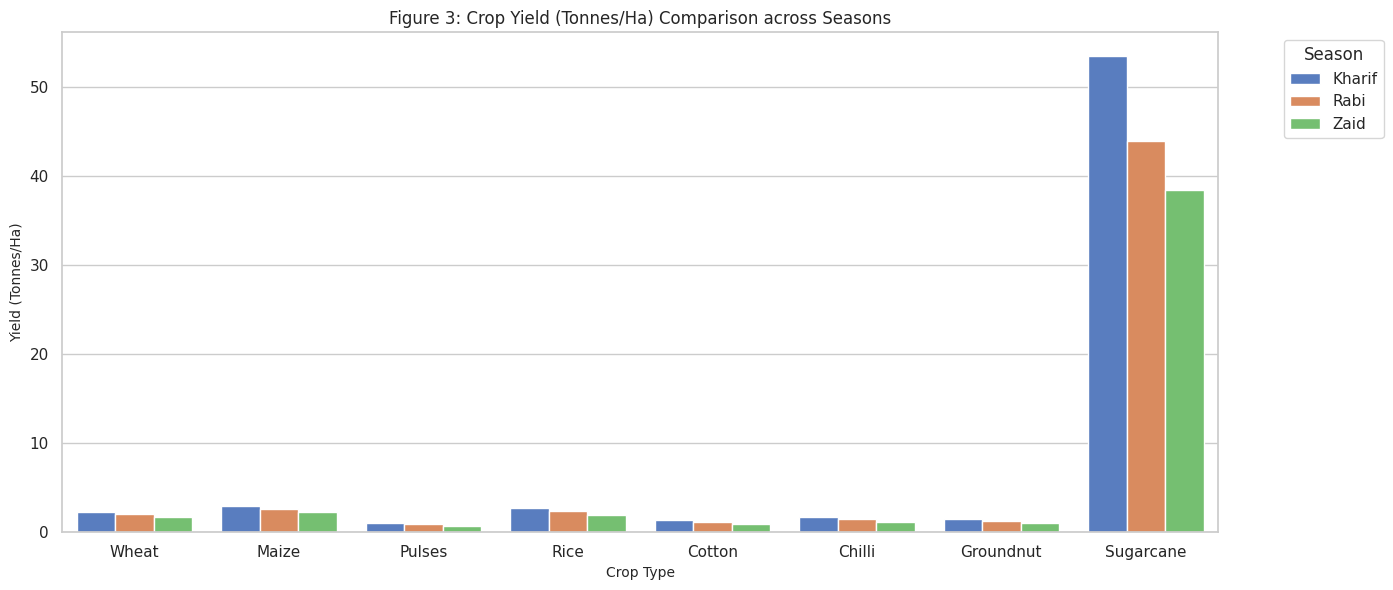

In [23]:
# Figure 3: Crop Performance Matrix Across Seasons
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', errorbar=None)
plt.title('Figure 3: Crop Yield (Tonnes/Ha) Comparison across Seasons')
plt.xlabel('Crop Type')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


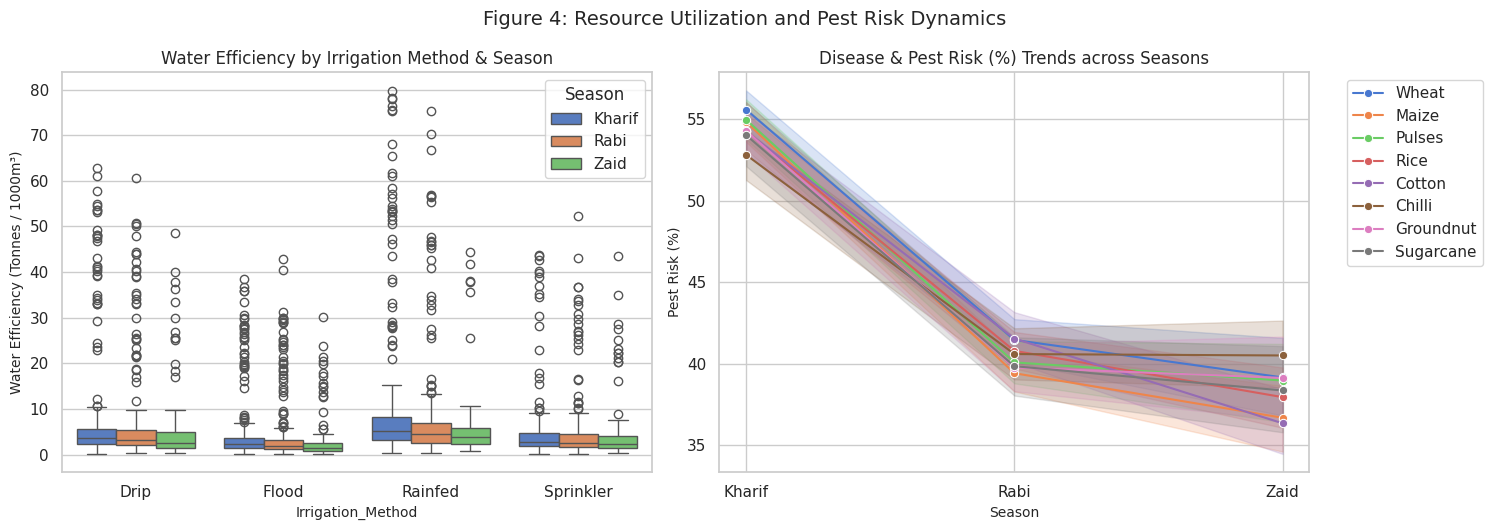

In [24]:
# Figure 4: Resource Efficiency & Risk Metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', ax=axes[0])
axes[0].set_title('Water Efficiency by Irrigation Method & Season')
axes[0].set_ylabel('Water Efficiency (Tonnes / 1000m³)')

sns.lineplot(data=df, x='Season', y='Disease_Pest_Risk_pct', hue='Crop', marker='o', ax=axes[1])
axes[1].set_title('Disease & Pest Risk (%) Trends across Seasons')
axes[1].set_ylabel('Pest Risk (%)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.suptitle('Figure 4: Resource Utilization and Pest Risk Dynamics', y=1.05)
plt.show()


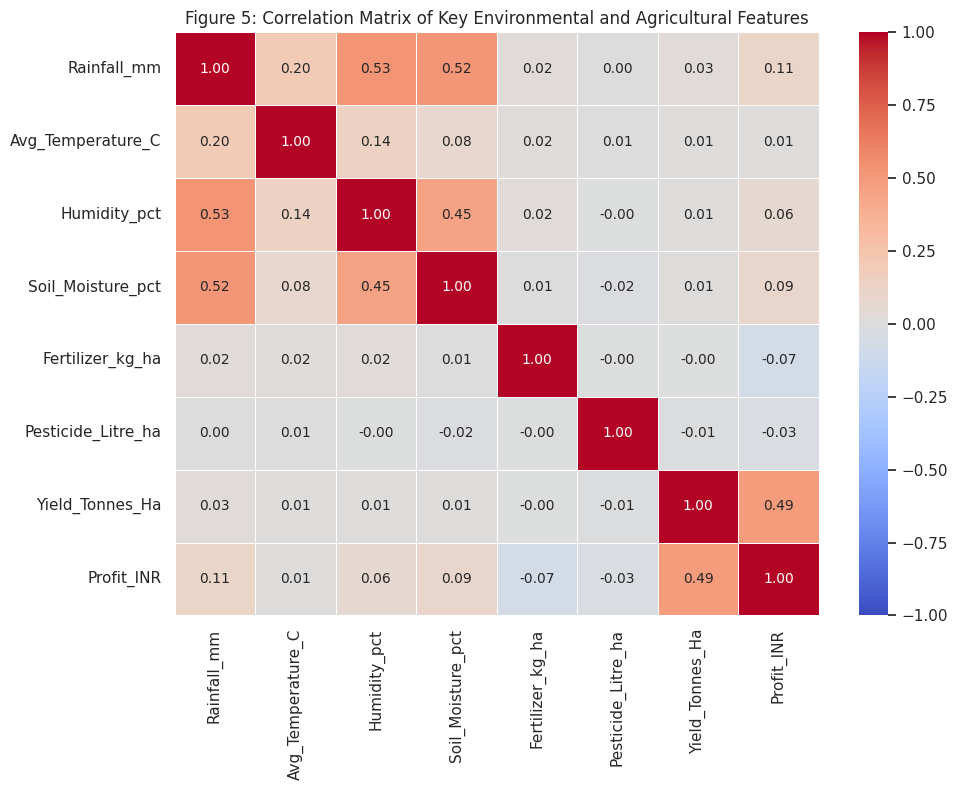

In [25]:
# Figure 5: Multivariate Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Figure 5: Correlation Matrix of Key Environmental and Agricultural Features')
plt.tight_layout()
plt.show()


## Section 10: Data-Driven Executive Summary

Unlike a fixed narrative written before seeing the results, every line below is generated from the values actually computed above — so it stays accurate even if you re-run this notebook on a refreshed or different dataset.

In [26]:
best_yield_season = seasonal_summary.loc[seasonal_summary['Mean_Yield'].idxmax(), 'Season']
best_profit_season = seasonal_summary.loc[seasonal_summary['Mean_Profit'].idxmax(), 'Season']
worst_profit_season = seasonal_summary.loc[seasonal_summary['Mean_Profit'].idxmin(), 'Season']
most_variable_state = state_cv.idxmax()
most_stable_state = state_cv.idxmin()

print("=" * 80)
print("DATA-DRIVEN SUMMARY")
print("=" * 80)

print(f"""
1. YIELD ACROSS SEASONS
   - ANOVA result: F={f_yield:.2f}, p={p_yield:.4f} -> {'a statistically significant' if p_yield < 0.05 else 'NO statistically significant'} difference in mean Yield across seasons.
   - {best_yield_season} shows the numerically highest mean yield ({seasonal_summary['Mean_Yield'].max():.2f} t/ha), but given the ANOVA result above, this gap {'is' if p_yield < 0.05 else 'is NOT'} large enough to call a genuine seasonal effect rather than random variation.

2. PROFIT ACROSS SEASONS
   - ANOVA result: F={f_profit:.2f}, p={p_profit:.2e} -> {'a statistically significant' if p_profit < 0.05 else 'no statistically significant'} difference in mean Profit across seasons.
   - {best_profit_season} is the most profitable season on average (₹{seasonal_summary['Mean_Profit'].max():,.0f}); {worst_profit_season} is the weakest (₹{seasonal_summary['Mean_Profit'].min():,.0f}).
   - Because Yield itself does not differ significantly by season but Profit does, the profit gap is likely driven more by cost/market-price dynamics than by physical crop output — worth investigating Market_Price_INR_Tonne and Total_Cost_INR by season directly if you want to confirm this.

3. ENVIRONMENT-YIELD RELATIONSHIPS
   - The strongest relationship in the correlation matrix is between {strongest_pair[0]} and {strongest_pair[1]} (r={strongest_val:.2f}) — an environmental co-occurrence, not a yield driver.
   - Correlations between environmental factors (rainfall, temperature, humidity, soil moisture) and Yield are all below |r|=0.15 in this dataset. This means, AT LEAST FOR THIS DATASET, environmental conditions alone do not linearly explain yield variation — any recommendation that assumes e.g. "more rainfall -> higher yield" should be flagged as not supported by this specific data.

4. REGIONAL CONSISTENCY
   - {most_variable_state} shows the most season-to-season swing in yield (CV={state_cv.max():.1f}%), while {most_stable_state} is the most seasonally stable (CV={state_cv.min():.1f}%).
   - Seasonal patterns are therefore NOT uniform across states — state-specific planning is more defensible than a single blanket seasonal recommendation.

5. OUTLIERS & DATA QUALITY
   - {len(outliers)} records ({len(outliers)/len(df)*100:.1f}%) are profit outliers by the IQR rule; retained in this analysis but worth a sensitivity check if conclusions are borderline.
""")


DATA-DRIVEN SUMMARY

1. YIELD ACROSS SEASONS
   - ANOVA result: F=1.46, p=0.2328 -> NO statistically significant difference in mean Yield across seasons.
   - Kharif shows the numerically highest mean yield (5.63 t/ha), but given the ANOVA result above, this gap is NOT large enough to call a genuine seasonal effect rather than random variation.

2. PROFIT ACROSS SEASONS
   - ANOVA result: F=34.29, p=1.71e-15 -> a statistically significant difference in mean Profit across seasons.
   - Kharif is the most profitable season on average (₹178,915); Zaid is the weakest (₹-24,805).
   - Because Yield itself does not differ significantly by season but Profit does, the profit gap is likely driven more by cost/market-price dynamics than by physical crop output — worth investigating Market_Price_INR_Tonne and Total_Cost_INR by season directly if you want to confirm this.

3. ENVIRONMENT-YIELD RELATIONSHIPS
   - The strongest relationship in the correlation matrix is between Rainfall_mm and Humidi

## Section 11: Limitations

- **Correlations between environmental variables and Yield/Profit are weak (|r| < 0.15)** across the board in this dataset — conclusions that assume strong causal environment→yield relationships are not supported by the numbers here and should be stated cautiously, or investigated further (e.g. non-linear effects, interaction terms).
- **State–District pairing looks synthetic**: the same district names (e.g. "Ludhiana", "Warangal") recur under multiple, geographically implausible states, suggesting state and district were assigned independently/randomly during data generation rather than reflecting real geography. Treat State/District-level findings as illustrative of the *analysis method*, not as real agronomic geography.
- **ANOVA's normality assumption is violated** (Shapiro-Wilk p ≈ 0 for all seasons), though this is expected at n>1000 and ANOVA remains reasonably robust; results should still be read as approximate rather than exact.
- Sample only covers three seasons and eight states — findings should not be generalized beyond the scope of this dataset.
